# Module 6: Continuous Time Markov Chains and Birth Death Processes

In the previous module, the Markov chain moved at fixed time steps: $X_0,X_1,X_2,\ldots$. In this module, the state changes happen at random times.

The main new idea is the holding time. When the process enters a nonabsorbing state, it stays there for a random amount of time before making the next jump. In a continuous time Markov chain, this holding time has an exponential distribution.

We first use a two state machine model to make the holding times easy to see. Then we look at a three state switching model, a birth death process, and a finite gas station model.

The examples follow the same pattern: define the generator matrix, simulate a path, interpret the holding times, and connect the simulation with the rates in the matrix.

## Libraries




In [22]:
import numpy as np
import matplotlib.pyplot as plt


In [23]:
FIGSIZE = (8, 4.5)
SMALL_FIGSIZE = (8, 3.5)
SUBPLOT_FIGSIZE = (8, 9)

HIST_ALPHA = 0.65
OVERLAP_ALPHA = 0.45

plt.rcParams["figure.figsize"] = FIGSIZE
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = False

plt.rcParams["lines.markersize"] = 4

## Model

A continuous time Markov chain is a process that moves between states in continuous time. In this module we only use finite state spaces, such as $E=\{0,1,\ldots,m-1\}$.

The process does not move at times $0,1,2,\ldots$. Instead, it stays in the current state for a random holding time. After that holding time, it jumps to a new state.

The jump rates are stored in a generator matrix $Q$. If $i\neq j$, then $q_{ij}$ is the rate of a jump from state $i$ to state $j$. The diagonal entries are chosen so that each row of $Q$ sums to zero:

$$
q_{ii}=-\sum_{j\neq i}q_{ij}.
$$

If the process is in state $i$, the total rate of leaving that state is

$$
q_i=\sum_{j\neq i}q_{ij}=-q_{ii}.
$$

The holding time in state $i$ has distribution $\mathrm{Exp}(q_i)$, so its mean is $1/q_i$. After the holding time ends, the next state is chosen using the probabilities

$$
P(\text{next state}=j\mid \text{leaving }i)=\frac{q_{ij}}{q_i},
\qquad j\neq i.
$$

Thus, the generator matrix controls two things: how long the process stays in each state, and where it jumps next.

### Helper functions

In [24]:
def simulate_ctmc(Q, x0, T_max, rng):
    """
    Simulate one path of a finite continuous time Markov chain.
    """

    n_states = Q.shape[0]

    times = [0.0]
    states = [x0]

    current_time = 0.0
    current_state = x0

    while current_time < T_max:
        # Total rate of leaving the current state
        rate = -Q[current_state, current_state]

        # If the leaving rate is zero, the state is absorbing
        if rate == 0:
            break

        # Holding time in the current state
        holding_time = rng.exponential(1 / rate)

        # Stop if the next jump would happen after T_max
        if current_time + holding_time > T_max:
            break

        # Update time to the next jump time
        current_time = current_time + holding_time

        # Jump probabilities from the current state
        probabilities = Q[current_state].copy()
        probabilities[current_state] = 0
        probabilities = probabilities / rate

        # Choose the next state
        next_state = rng.choice(
            n_states,
            p=probabilities
        )

        times.append(current_time)
        states.append(next_state)

        current_state = next_state

    return np.array(times), np.array(states)

In [25]:
def plot_ctmc_path(times, states, T_max, title, y_ticks=None, y_ticklabels=None, ylabel="State"):
    """
    Plot one continuous time Markov chain sample path.
    """

    plot_times = np.append(times, T_max)
    plot_states = np.append(states, states[-1])

    plt.figure(figsize=SMALL_FIGSIZE)

    plt.step(
        plot_times,
        plot_states,
        where="post"
    )

    if y_ticks is not None:
        if y_ticklabels is None:
            plt.yticks(y_ticks)
        else:
            plt.yticks(y_ticks, y_ticklabels)

    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [26]:
def stationary_distribution_ctmc(Q):
    """
    Compute the unique stationary distribution of a finite continuous time Markov chain.

    This function assumes that the stationary distribution is unique.
    """

    n = Q.shape[0]

    A = Q.T.copy()
    A[-1, :] = np.ones(n)

    b = np.zeros(n)
    b[-1] = 1

    pi = np.linalg.solve(A, b)

    return pi

## Example 1: A two state machine model

We start with the smallest possible continuous time Markov chain. There are only two states.

Suppose a machine can be in one of two states:

$$
0=\text{working}, \qquad 1=\text{under repair}.
$$

The machine works for a random amount of time before it fails. It then stays under repair for a random amount of time before it becomes working again.

This example is used to see holding times clearly. Each horizontal segment in the path is one holding time. Since holding times are exponential, their lengths are random and can vary a lot from one visit to the next.

We use the generator matrix

$$
Q=
\begin{pmatrix}
-\alpha & \alpha\\
\beta & -\beta
\end{pmatrix}.
$$

Here $\alpha$ is the failure rate, and $\beta$ is the repair rate. From state $0$, the holding time has distribution $\mathrm{Exp}(\alpha)$. From state $1$, the holding time has distribution $\mathrm{Exp}(\beta)$.

Generator matrix Q:
[[-0.25  0.25]
 [ 0.15 -0.15]]

Row sums:
[0. 0.]

First few visited states and holding times:
state 0, holding time 4.23
state 1, holding time 2.58
state 0, holding time 0.20
state 1, holding time 10.66
state 0, holding time 7.25
state 1, holding time 0.67
state 0, holding time 1.56
state 1, holding time 0.63
state 0, holding time 4.19
state 1, holding time 6.63


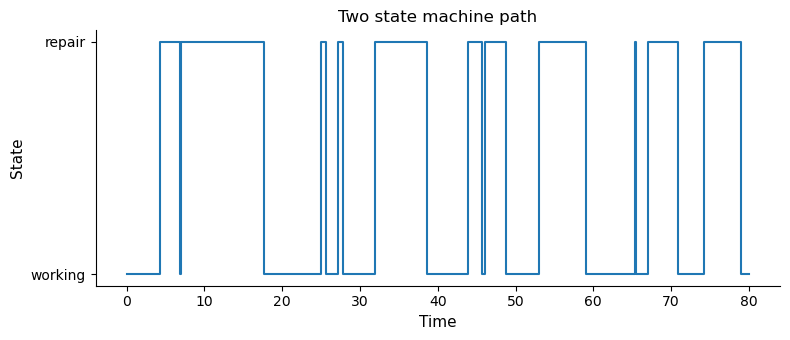

In [27]:
# Failure rate: working -> under repair
alpha = 0.25

# Repair rate: under repair -> working
beta = 0.15

Q_machine = np.array([
    [-alpha, alpha],
    [beta, -beta]
])

print("Generator matrix Q:")
print(Q_machine)

print()
print("Row sums:")
print(Q_machine.sum(axis=1))

# Simulate one path
T_max = 80
x0 = 0

# Generate a new path each time
rng = np.random.default_rng()

times_machine, states_machine = simulate_ctmc(
    Q_machine,
    x0,
    T_max,
    rng
)

# Compute holding times completed before the time horizon
holding_times_machine = np.diff(times_machine)

print()
print("First few visited states and holding times:")
for state, duration in zip(states_machine[:-1][:10], holding_times_machine[:10]):
    print(f"state {state}, holding time {duration:.2f}")

plot_ctmc_path(
    times_machine,
    states_machine,
    T_max,
    title="Two state machine path",
    y_ticks=[0, 1],
    y_ticklabels=["working", "repair"]
)

The path is one realization of the machine model. The horizontal axis is time, and the vertical axis is the current state.

Each horizontal segment is one holding time. The segment lengths are not fixed. They are sampled from exponential distributions. In this example, the holding time in the working state has distribution $\mathrm{Exp}(\alpha)$, and the holding time in the repair state has distribution $\mathrm{Exp}(\beta)$.

The process does not jump at integer times. It jumps after random waiting times. This is the main difference from the discrete time Markov chains in the previous module.

### Task 1

Simulate another path of the two state machine model. Use the same generator matrix $Q$, but change the initial state to

$$
X(0)=1.
$$

This means that the machine starts under repair. Use `simulate_ctmc()` to simulate the path, and then use `plot_ctmc_path()` to draw it.


In [28]:
# Simulate the machine path from the repair state.

# Use x0_task = 1 to start under repair.

# Use T_max_task = 80.

# Create a random generator.

# Use simulate_ctmc() with Q_machine.



### Solution

The only change is the initial state. We use $X(0)=1$, so the machine starts under repair.

The generator matrix is still the same. The holding times are still exponential, with rate $\alpha$ in the working state and rate $\beta$ in the repair state.

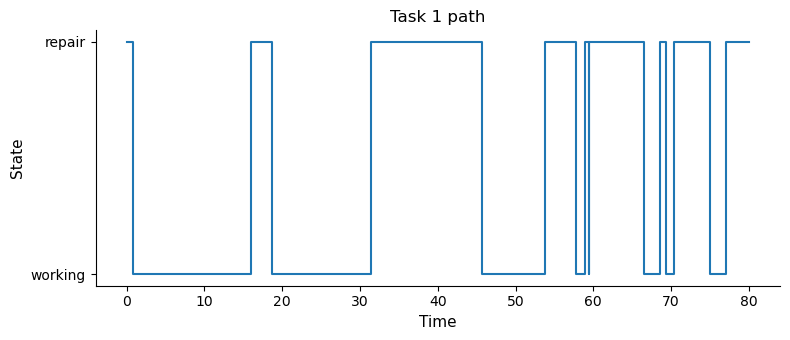

In [29]:
# Solution to Task 1

# Initial state: start under repair
x0_task = 1

# Time horizon
T_max_task = 80

# Generate a new path each time
rng = np.random.default_rng()

# Simulate one path
times_task, states_task = simulate_ctmc(
    Q_machine,
    x0_task,
    T_max_task,
    rng
)

plot_ctmc_path(
    times_task,
    states_task,
    T_max_task,
    title="Task 1 path",
    y_ticks=[0, 1],
    y_ticklabels=["working", "repair"]
)

The new path starts in the repair state. After a random repair holding time, the machine returns to the working state.


### Holding time distribution

One path shows a few holding times. To see the exponential distribution more clearly, we now simulate many holding times from each state.

From the working state, the holding time has distribution $\mathrm{Exp}(\alpha)$. From the repair state, the holding time has distribution $\mathrm{Exp}(\beta)$.

In [30]:
# Draw many holding times to check the exponential model
n_samples = 5000

rng = np.random.default_rng()

working_holding_times = rng.exponential(
    1 / alpha,
    size=n_samples
)

repair_holding_times = rng.exponential(
    1 / beta,
    size=n_samples
)

print("Mean simulated working time:")
print(np.mean(working_holding_times))

print("Theoretical mean working time:")
print(1 / alpha)

print()
print("Mean simulated repair time:")
print(np.mean(repair_holding_times))

print("Theoretical mean repair time:")
print(1 / beta)

Mean simulated working time:
3.97823763380992
Theoretical mean working time:
4.0

Mean simulated repair time:
6.755208872988046
Theoretical mean repair time:
6.666666666666667


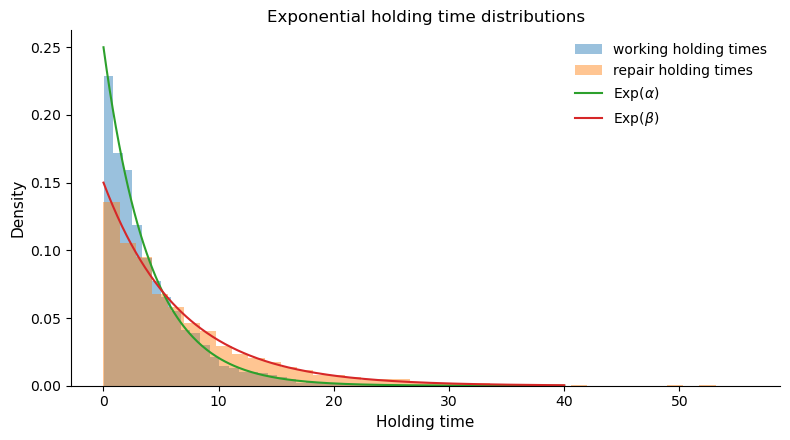

In [31]:
# Compare simulated holding times with exponential densities
x_values = np.linspace(0, 40, 300)

working_density = alpha * np.exp(-alpha * x_values)
repair_density = beta * np.exp(-beta * x_values)

plt.figure(figsize=FIGSIZE)

plt.hist(
    working_holding_times,
    bins=40,
    density=True,
    alpha=OVERLAP_ALPHA,
    label="working holding times"
)

plt.hist(
    repair_holding_times,
    bins=40,
    density=True,
    alpha=OVERLAP_ALPHA,
    label="repair holding times"
)

plt.plot(
    x_values,
    working_density,
    label=r"$\mathrm{Exp}(\alpha)$"
)

plt.plot(
    x_values,
    repair_density,
    label=r"$\mathrm{Exp}(\beta)$"
)

plt.xlabel("Holding time")
plt.ylabel("Density")
plt.title("Exponential holding time distributions")
plt.legend()
plt.tight_layout()
plt.show()

The curves give the corresponding exponential densities. The working state has leaving rate $\alpha=0.25$, so its mean holding time is $1/\alpha=4$. The repair state has leaving rate $\beta=0.15$, so its mean holding time is $1/\beta\approx 6.67$.

Since $\beta<\alpha$, the repair holding times are longer on average. This is visible in the plot because the repair distribution decreases more slowly and has a longer right tail.

### Stationary distribution

The same two state chain also has a long run distribution. This connects with the stationary distributions from the previous module, but the equation is now written with the generator matrix $Q$.

The stationary distribution satisfies

$$
\pi Q=0,
\qquad
\pi_0+\pi_1=1.
$$

For this two state machine model,

$$
\pi_0=\frac{\beta}{\alpha+\beta},
\qquad
\pi_1=\frac{\alpha}{\alpha+\beta}.
$$

The state with the smaller leaving rate usually has the larger long run probability, because the process tends to stay there longer.

In [32]:
pi_machine = np.array([
    beta / (alpha + beta),
    alpha / (alpha + beta)
])

print("Stationary distribution:")
print(pi_machine)

print()
print("Check pi Q:")
print(pi_machine @ Q_machine)

print()
print("State labels:")
print("0: working")
print("1: repair")

Stationary distribution:
[0.375 0.625]

Check pi Q:
[ 1.04083409e-17 -1.04083409e-17]

State labels:
0: working
1: repair


## Example 2: A three state switching model

The two state machine model had only one possible next state from each state. We now use three states, so that the next state may be chosen from several possibilities.

Suppose a simple system can be in one of three modes:

$$
0=\text{idle},\qquad 1=\text{active},\qquad 2=\text{repair}.
$$

The generator matrix is

$$
Q=
\begin{pmatrix}
-0.25 & 0.20 & 0.05\\
0.15 & -0.35 & 0.20\\
0.10 & 0.25 & -0.35
\end{pmatrix}.
$$

The diagonal entries give the total leaving rates. For example, from state $0$, the total leaving rate is $0.25$. After the holding time ends, the process jumps to state $1$ with probability $0.20/0.25$ and to state $2$ with probability $0.05/0.25$.

The rates are chosen so that the default path has fewer jumps. This makes the different holding times easier to see.

Row sums of Q:
[0. 0. 0.]

First five visited states and holding times:
idle, holding time 1.35
active, holding time 0.15
idle, holding time 0.88
active, holding time 3.84
idle, holding time 3.79


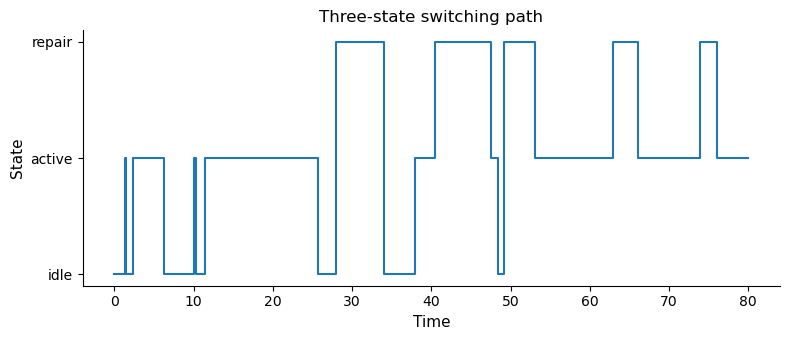

In [33]:
# Generator matrix for the three-state switching model
Q_switch = np.array([
    [-0.25, 0.20, 0.05],
    [0.15, -0.35, 0.20],
    [0.10, 0.25, -0.35]
])

mode_labels = ["idle", "active", "repair"]

print("Row sums of Q:")
print(np.round(Q_switch.sum(axis=1), 10))

# Simulate one path
T_max_switch = 80
x0_switch = 0

rng = np.random.default_rng()

times_switch, states_switch = simulate_ctmc(
    Q_switch,
    x0_switch,
    T_max_switch,
    rng
)

# Compute holding times completed before the time horizon
holding_times_switch = np.diff(times_switch)

print()
print("First five visited states and holding times:")
for state, duration in zip(states_switch[:-1][:5], holding_times_switch[:5]):
    print(f"{mode_labels[state]}, holding time {duration:.2f}")

plot_ctmc_path(
    times_switch,
    states_switch,
    T_max_switch,
    title="Three-state switching path",
    y_ticks=[0, 1, 2],
    y_ticklabels=mode_labels
)

The process still stays constant between jumps. Each horizontal segment is a holding time, and the holding time in state $i$ has exponential rate $q_i=-q_{ii}$.

The new point is the jump choice. When the holding time ends, there may be more than one possible next state. The probabilities are obtained by dividing the outgoing rates by the total leaving rate.

### Task 2

Use the generator matrix `Q_switch`. For state $0$, find the total leaving rate. Then compute the probability that the next state is $1$, given that the process leaves state $0$, and the probability that the next state is $2$, given that the process leaves state $0$. Write a short code cell to compute these three values.


In [34]:
# Compute the leaving rate and jump probabilities from state 0.

# Use row 0 of Q_switch.


### Solution

The total leaving rate from state $0$ is

$$
q_0=-q_{00}=0.25.
$$

The outgoing rates are $q_{01}=0.20$ and $q_{02}=0.05$. Therefore,

$$
P(\text{next state}=1\mid \text{leaving }0)=\frac{0.20}{0.25}=0.8,
$$

and

$$
P(\text{next state}=2\mid \text{leaving }0)=\frac{0.05}{0.25}=0.2.
$$

In [35]:
# Solution to Task 2

# Current state
state = 0

# Total leaving rate from state 0
leaving_rate = -Q_switch[state, state]

# Jump probabilities from state 0
prob_to_1 = Q_switch[state, 1] / leaving_rate
prob_to_2 = Q_switch[state, 2] / leaving_rate

print("Leaving rate from state 0:")
print(leaving_rate)

print()
print("Probability of jumping to state 1:")
print(prob_to_1)

print("Probability of jumping to state 2:")
print(prob_to_2)

Leaving rate from state 0:
0.25

Probability of jumping to state 1:
0.8
Probability of jumping to state 2:
0.2


The probabilities add up to one because they are conditional on the event that the process leaves state $0$.

This task separates the two roles of the generator matrix. The diagonal entry gives the exponential holding time rate, while the off diagonal entries determine the next state probabilities after leaving.

## Example 3: A birth death process

A birth death process is a continuous time Markov chain whose states are ordered as

$$
0,1,2,\ldots.
$$

The process can only move to a neighbouring state. From state $i$, it can jump to $i+1$ or to $i-1$.

The upward jumps are called births, and the downward jumps are called deaths. In a finite model with states $0,1,\ldots,r$, the generator matrix has nonzero entries only near the diagonal.

In this example we simulate a finite birth death process. The main point is the structure of the path: the state can only change by one step at a jump time.

In [36]:
# Number of states
r = 6
n_states_bd = r + 1

# Birth rates lambda_i for jumps i -> i + 1
birth_rates = np.array([0.35, 0.35, 0.30, 0.25, 0.20, 0.15])

# Death rates mu_i for jumps i -> i - 1
death_rates = np.array([0.20, 0.25, 0.30, 0.35, 0.40, 0.45])

# Generator matrix
Q_bd = np.zeros((n_states_bd, n_states_bd))

# Fill birth rates
for i in range(r):
    Q_bd[i, i + 1] = birth_rates[i]

# Fill death rates
for i in range(1, r + 1):
    Q_bd[i, i - 1] = death_rates[i - 1]

# Fill diagonal entries so that rows sum to zero
for i in range(n_states_bd):
    Q_bd[i, i] = -np.sum(Q_bd[i])

print("Generator matrix Q:")
print(Q_bd)

print()
print("Row sums:")
print(np.round(Q_bd.sum(axis=1), 10) + 0.0)

Generator matrix Q:
[[-0.35  0.35  0.    0.    0.    0.    0.  ]
 [ 0.2  -0.55  0.35  0.    0.    0.    0.  ]
 [ 0.    0.25 -0.55  0.3   0.    0.    0.  ]
 [ 0.    0.    0.3  -0.55  0.25  0.    0.  ]
 [ 0.    0.    0.    0.35 -0.55  0.2   0.  ]
 [ 0.    0.    0.    0.    0.4  -0.55  0.15]
 [ 0.    0.    0.    0.    0.    0.45 -0.45]]

Row sums:
[0. 0. 0. 0. 0. 0. 0.]


The matrix has a special structure. From an interior state, the process can only move one step up or one step down.

For example, from state $3$, the only possible next states are $2$ and $4$. All other direct jumps from state $3$ have rate zero.

This structure is useful in many applied models. A birth may represent an arrival, a new customer, or an increase in population size. A death may represent a service completion, a departure, or a decrease in population size.

First few visited states and holding times:
state 2, holding time 0.68
state 3, holding time 0.79
state 2, holding time 0.94
state 3, holding time 0.17
state 4, holding time 1.32
state 5, holding time 2.92
state 4, holding time 0.06
state 3, holding time 0.50
state 4, holding time 0.45
state 5, holding time 2.21


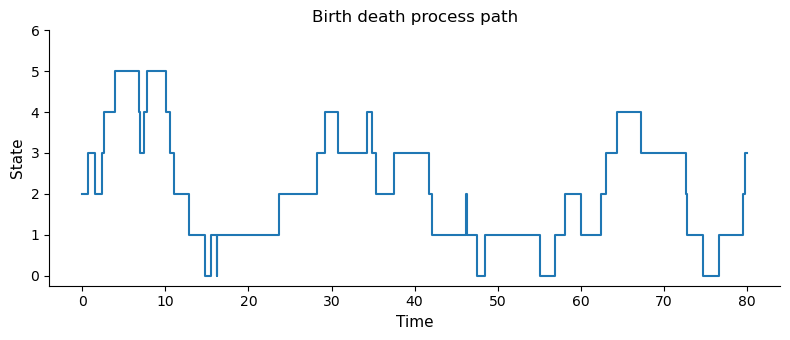

In [37]:
# Simulate one birth death path
T_max_bd = 80
x0_bd = 2

rng = np.random.default_rng()

times_bd, states_bd = simulate_ctmc(
    Q_bd,
    x0_bd,
    T_max_bd,
    rng
)

# Compute holding times completed before the time horizon
holding_times_bd = np.diff(times_bd)

print("First few visited states and holding times:")
for state, duration in zip(states_bd[:-1][:10], holding_times_bd[:10]):
    print(f"state {state}, holding time {duration:.2f}")

plot_ctmc_path(
    times_bd,
    states_bd,
    T_max_bd,
    title="Birth death process path",
    y_ticks=range(n_states_bd)
)

The state can only move by one step at a time. This is the main visual difference from a general continuous time Markov chain, where a state may jump to several non neighbouring states.

The holding times are still exponential. The rate depends on the current state through the total rate of leaving that state.

### Task 3

Use the generator matrix `Q_bd`. For state $3$, find the total leaving rate. Then compute the probability that the next state is $2$ and the probability that the next state is $4$. Write a short code cell to compute these values.


In [38]:
# Compute the leaving rate and jump probabilities from state 3.

# Use state = 3.


### Solution

From state $3$, the process can jump only to state $2$ or state $4$.

The total leaving rate is

$$
q_3=-q_{33}.
$$

The jump probabilities are obtained by dividing the outgoing rates by this total leaving rate.

In [39]:
# Solution to Task 3

# Current state
state = 3

# Total leaving rate from state 3
leaving_rate = -Q_bd[state, state]

# Jump probabilities
prob_to_2 = Q_bd[state, 2] / leaving_rate
prob_to_4 = Q_bd[state, 4] / leaving_rate

print("Leaving rate from state 3:")
print(leaving_rate)

print()
print("Probability of jumping to state 2:")
print(prob_to_2)

print("Probability of jumping to state 4:")
print(prob_to_4)

Leaving rate from state 3:
0.55

Probability of jumping to state 2:
0.5454545454545454
Probability of jumping to state 4:
0.45454545454545453


The diagonal entry gives the exponential holding time rate, and the outgoing rates give the next state probabilities after leaving. The difference is that a birth death process has a simpler structure. From each interior state, only the two neighbouring states can be reached directly.

The birth death structure appears in many queueing models.

In the next example, the state will be the number of cars at a gas station. An arrival increases the state by one, and a completed service decreases the state by one. This gives a finite birth death process with a direct application meaning.

## Example 4: A finite gas station model

We now use a birth death process in a queueing example.

Suppose a small gas station has two pumps and one waiting space. Cars arrive randomly, and service times are exponential. If both pumps are occupied and one car is already waiting, the system is full. A new arriving car then leaves and is not added to the system.

Let

$$
X(t)=\text{number of cars at the gas station at time }t.
$$

The state space is

$$
E=\{0,1,2,3\}.
$$

State $0$ means that the station is empty. State $3$ means that both pumps and the waiting space are occupied.

Cars arrive with rate $\lambda$. Each pump serves cars with rate $\mu$. When two cars are in service, the total service rate is $2\mu$.

The generator matrix is

$$
Q=
\begin{pmatrix}
-\lambda & \lambda & 0 & 0\\
\mu & -(\lambda+\mu) & \lambda & 0\\
0 & 2\mu & -(\lambda+2\mu) & \lambda\\
0 & 0 & 2\mu & -2\mu
\end{pmatrix}.
$$

The upward jumps are arrivals. The downward jumps are completed services.

There is no transition from state $3$ to state $4$, because the system has no more space. Arrivals that occur while the process is in state $3$ are lost.

In [40]:
# Arrival rate: cars per hour
lambda_rate = 30

# Service rate of one pump: cars per hour
mu_rate = 20

# Generator matrix for the gas station model
Q_gas = np.array([
    [-lambda_rate, lambda_rate, 0.0, 0.0],
    [mu_rate, -(lambda_rate + mu_rate), lambda_rate, 0.0],
    [0.0, 2 * mu_rate, -(lambda_rate + 2 * mu_rate), lambda_rate],
    [0.0, 0.0, 2 * mu_rate, -2 * mu_rate]
])

print("Generator matrix Q:")
print(Q_gas)

print()
print("Row sums:")
print(Q_gas.sum(axis=1))

Generator matrix Q:
[[-30.  30.   0.   0.]
 [ 20. -50.  30.   0.]
 [  0.  40. -70.  30.]
 [  0.   0.  40. -40.]]

Row sums:
[0. 0. 0. 0.]


We first simulate one path of the process.

The path shows how the number of cars changes over time. An upward jump means that a car arrives. A downward jump means that a service is completed.

First few visited states and holding times:
state 0, holding time 0.0919 hours
state 1, holding time 0.0404 hours
state 2, holding time 0.0205 hours
state 3, holding time 0.0215 hours
state 2, holding time 0.0091 hours
state 1, holding time 0.0232 hours
state 0, holding time 0.0045 hours
state 1, holding time 0.0087 hours
state 0, holding time 0.0134 hours
state 1, holding time 0.0148 hours


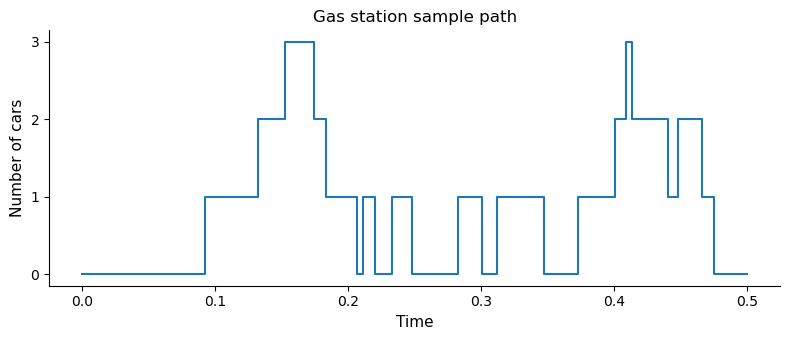

In [41]:
# Simulate one gas station path
T_max_gas = 0.5
x0_gas = 0

rng = np.random.default_rng()

times_gas, states_gas = simulate_ctmc(
    Q_gas,
    x0_gas,
    T_max_gas,
    rng
)

# Compute holding times completed before the time horizon
holding_times_gas = np.diff(times_gas)

print("First few visited states and holding times:")
for state, duration in zip(states_gas[:-1][:10], holding_times_gas[:10]):
    print(f"state {state}, holding time {duration:.4f} hours")

plot_ctmc_path(
    times_gas,
    states_gas,
    T_max_gas,
    title="Gas station sample path",
    y_ticks=range(4),
    ylabel="Number of cars"
)

The path is one realization of the gas station process. The vertical axis is the number of cars in the system.

When the state is $0$, the station is empty. When the state is $1$ or $2$, there is at least one car being served. When the state is $3$, the station is full.

The path does not show lost cars directly. A lost car arrives when the process is already in state $3$, so the state remains $3$.

### Stationary distribution and blocking probability

The stationary distribution gives the long run fraction of time spent in each state.

For the gas station, state $3$ is especially important. It is the full state. Therefore, the stationary probability of state $3$ is the blocking probability.

In [42]:
# Stationary distribution
pi_gas = stationary_distribution_ctmc(Q_gas)

# State labels
gas_states = np.arange(4)

# Expected number of cars in the system
expected_cars = np.sum(gas_states * pi_gas)

# Blocking probability: probability that the system is full
blocking_probability = pi_gas[3]

# Average number of lost cars per hour
lost_cars_per_hour = lambda_rate * blocking_probability

print("Stationary distribution:")
for state in gas_states:
    print(f"state {state}: {pi_gas[state]:.4f}")

print()
print("Expected number of cars:")
print(expected_cars)

print()
print("Blocking probability:")
print(blocking_probability)

print()
print("Average number of lost cars per hour:")
print(lost_cars_per_hour)

Stationary distribution:
state 0: 0.2238
state 1: 0.3357
state 2: 0.2517
state 3: 0.1888

Expected number of cars:
1.4055944055944054

Blocking probability:
0.1888111888111888

Average number of lost cars per hour:
5.664335664335664


The stationary distribution gives the long run fraction of time spent in each state. State $3$ is the full state. For Poisson arrivals, the long run probability that an arriving car sees the system full is the stationary probability $\pi_3$. Therefore, $\pi_3$ is the blocking probability.

Multiplying $\pi_3$ by the arrival rate gives the average number of lost cars per hour. The expected number of cars is computed from the stationary distribution by weighting each state by its number of cars.